# Double-Pendulum Forecasting Test Case

We consider the planar double pendulum as a forecasting benchmark. The state is

$$
x(t) = [\theta_1(t), \omega_1(t), \theta_2(t), \omega_2(t)]^\top,
$$

where $\theta_1$ and $\theta_2$ are the angular displacements and $\omega_1$ and $\omega_2$ are the corresponding angular velocities. Initial conditions are sampled from

$$
\theta_1(0), \theta_2(0) \in [-\pi/3,\, \pi/3], \qquad \omega_1(0), \omega_2(0) \in [-1,\, 1].
$$

For the present benchmark, we use one high-fidelity observation and several low-fidelity observations of the **same** underlying clean trajectory, with total duration $10$ seconds. The high-fidelity data are corrupted with the time-dependent noise law

$$
\sigma_{\mathrm{HF}}(t) = 0.01\,\|\omega(t)\|,
$$

while the low-fidelity trajectories use

$$
\sigma_{\mathrm{LF}}(t) = 0.10\,\|\omega(t)\|,
$$

with

$$
\|\omega(t)\| = \sqrt{\omega_1(t)^2 + \omega_2(t)^2}.
$$

To identify the dynamics, we fit the current three-model comparison implemented in the source: `HF`, `LF`, and `MF`. Each noisy observation is paired directly with its own spatiotemporal variance profile and fitted through the weighted weak library, with no extra trajectory-level sample weights. The feature library is selected below through the `LIBRARY_KIND` flag so that the same notebook can compare the physics-informed double-pendulum basis against the degree-3 polynomial baseline.

In [1]:
import matplotlib.pyplot as plt
import tqdm
import numpy as np

from mfsindy.cases.double_pendulum_forecasting import (
    DEFAULT_HF_NOISE_SCALE,
    DEFAULT_LIBRARY_KIND,
    DEFAULT_LF_NOISE_SCALE,
    DEFAULT_OMEGA_RANGE,
    DEFAULT_POLY_DEGREE,
    DEFAULT_THETA_RANGE,
    benchmark_double_pendulum_fidelities,
    build_double_pendulum_dataset,
    compute_double_pendulum_derivatives,
    evaluate_double_pendulum_models,
    evaluate_ensemble_sindy_derivatives,
    fit_double_pendulum_hf_lf_models,
    format_weighted_weak_equations,
    simulate_double_pendulum_trajectory,
    simulate_ensemble_sindy_forecast,
    summarize_fidelity_benchmark,
    summarize_ensemble_forecast,
)

seed = 0
LIBRARY_KIND = "polynomial"  # switch to "polynomial" to compare
dataset = build_double_pendulum_dataset(
    n_hf=1,
    n_lf=10,
    t_final=10.0,
    dt=0.01,
    hf_noise_scale=DEFAULT_HF_NOISE_SCALE,
    lf_noise_scale=DEFAULT_LF_NOISE_SCALE,
    seed=seed,
)

t = dataset.t
hf_clean = dataset.hf.clean[0]
hf_noisy = dataset.hf.noisy[0]
hf_variance = dataset.hf.variance[0]
lf_clean = dataset.lf.clean
lf_noisy = dataset.lf.noisy
lf_variance = dataset.lf.variance

theta1, omega1, theta2, omega2 = hf_clean.T
hf_theta1, hf_omega1, hf_theta2, hf_omega2 = hf_noisy.T

seed, DEFAULT_THETA_RANGE, DEFAULT_OMEGA_RANGE, DEFAULT_POLY_DEGREE, LIBRARY_KIND


(0, (-1.0471975511965976, 1.0471975511965976), (-0.0, 0.0), 3, 'polynomial')

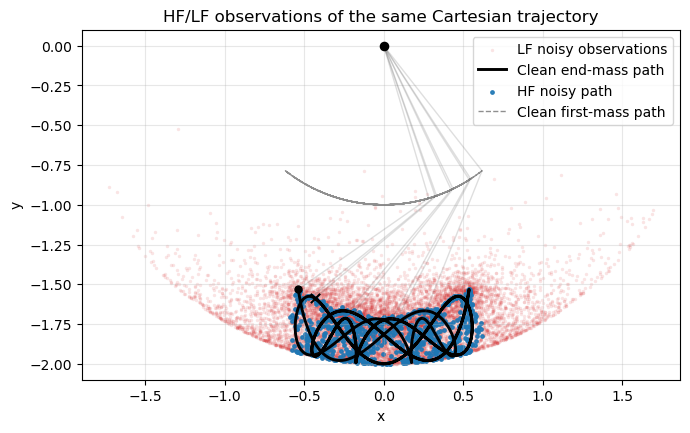

In [2]:
def cartesian_positions(theta1, theta2):
    x1 = np.sin(theta1)
    y1 = -np.cos(theta1)
    x2 = x1 + np.sin(theta2)
    y2 = y1 - np.cos(theta2)
    return x1, y1, x2, y2


x1, y1, x2, y2 = cartesian_positions(theta1, theta2)
hf_x1, hf_y1, hf_x2, hf_y2 = cartesian_positions(hf_theta1, hf_theta2)

fig, ax = plt.subplots(figsize=(7, 7))

for idx, lf_traj in enumerate(lf_noisy):
    _, _, lf_x2, lf_y2 = cartesian_positions(lf_traj[:, 0], lf_traj[:, 2])
    ax.scatter(
        lf_x2,
        lf_y2,
        s=6,
        color="#d62728",
        alpha=0.12,
        linewidths=0.0,
        label="LF noisy observations" if idx == 0 else None,
    )

ax.plot(x2, y2, color="black", lw=2.1, label="Clean end-mass path")
ax.scatter(hf_x2, hf_y2, color="#1f77b4", s=6, alpha=0.9, label="HF noisy path")
ax.plot(x1, y1, color="0.45", lw=1.0, ls="--", alpha=0.8, label="Clean first-mass path")

snapshot_idx = np.linspace(0, len(t) - 1, 8, dtype=int)
for idx in snapshot_idx:
    ax.plot(
        [0, x1[idx], x2[idx]],
        [0, y1[idx], y2[idx]],
        color="0.3",
        alpha=0.18,
        lw=1.0,
    )

ax.scatter([0], [0], color="black", s=35, zorder=5)
ax.scatter([x2[0]], [y2[0]], color="black", s=25, marker="o", zorder=5)
ax.scatter([x2[-1]], [y2[-1]], color="black", s=45, marker="x", zorder=5)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("HF/LF observations of the same Cartesian trajectory")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()


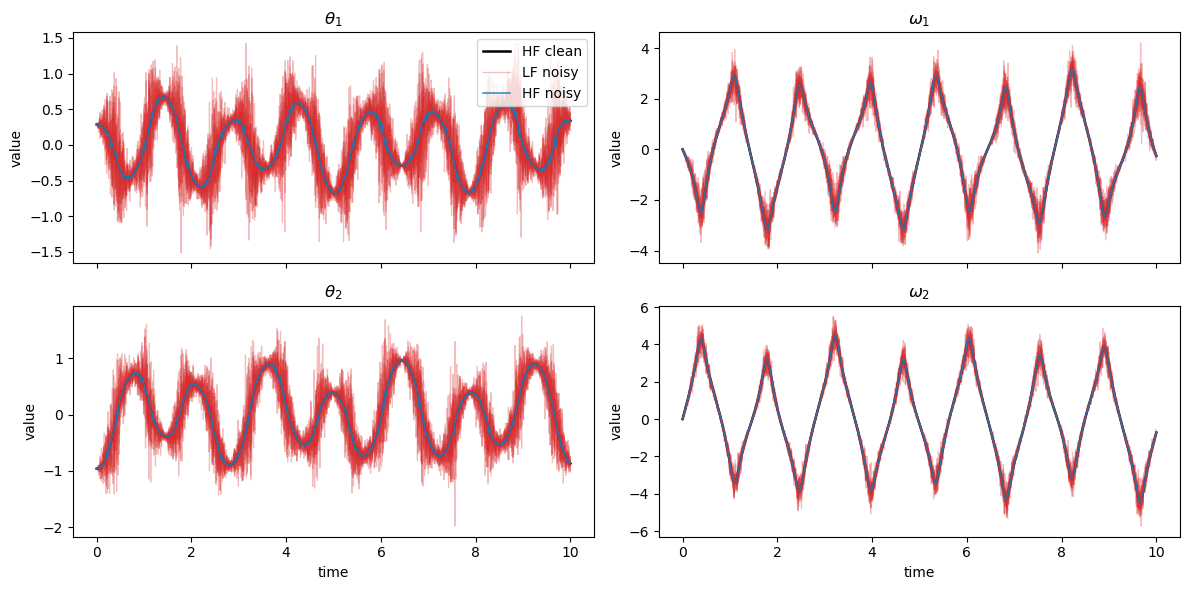

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
state_labels = [r"$\theta_1$", r"$\omega_1$", r"$\theta_2$", r"$\omega_2$"]

for idx, ax in enumerate(axes.ravel()):
    ax.plot(t, hf_clean[:, idx], color="black", lw=1.8, label="HF clean")
    for lf_idx in range(lf_noisy.shape[0]):
        label = "LF noisy" if idx == 0 and lf_idx == 0 else None
        ax.plot(t, lf_noisy[lf_idx, :, idx], color="#d62728", lw=0.9, alpha=0.3, label=label)
    ax.plot(t, hf_noisy[:, idx], color="#1f77b4", lw=1.1, alpha=0.9, label="HF noisy")
    ax.set_title(state_labels[idx])
    ax.set_ylabel("value")

axes[1, 0].set_xlabel("time")
axes[1, 1].set_xlabel("time")
axes[0, 0].legend(loc="upper right")
plt.tight_layout()


## Weighted Weak-SINDy Fit

All three models below use the same weighted weak library and the same `LIBRARY_KIND` choice from the setup cell. The only difference is the observation pool that is stacked before the ensemble optimizer is applied:

- `HF`: the single high-fidelity observation,
- `LF`: the five low-fidelity observations,
- `MF`: the full set of one HF plus five LF observations.

In every case, the spatiotemporal weights are the corresponding variance profiles $\sigma(t)^2$, and no additional sample-weight correction is introduced.

In [4]:
fit_results = fit_double_pendulum_hf_lf_models(
    dataset,
    library_kind=LIBRARY_KIND,
    poly_degree=DEFAULT_POLY_DEGREE,
    stlsq_threshold=0.5,
    stlsq_alpha=1e-12,
    n_ensemble_models=25,
    weak_seed=seed,
    n_weak_cells=200,
    weak_window_length=0.05
)

model_titles = {
    "HF": "HF weighted weak-SINDy model",
    "LF": "LF weighted weak-SINDy model",
    "MF": "MF fidelity-weighted weak-SINDy model",
}

for model_name, result in fit_results.items():
    print(model_titles[model_name])
    print(f"number of retained features: {np.count_nonzero(np.abs(result.coefficients) > 1e-12)}")
    for equation in format_weighted_weak_equations(result.coefficients, result.feature_names):
        print(equation)
    print()


/Users/filippozacchei/anaconda3/envs/mfsindy/lib/python3.12/site-packages/pysindy/utils/_axes.py:125: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Users/filippozacchei/anaconda3/envs/mfsindy/lib/python3.12/site-packages/pysindy/utils/_axes.py:125: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Users/filippozacchei/anaconda3/envs/mfsindy/lib/python3.12/site-packages/pysindy/utils/_axes.py:125: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(


HF weighted weak-SINDy model
number of retained features: 28
theta1_dot = 1.021 omega1
omega1_dot = -5.530 theta1 - 4.173 theta2 + 5.549 theta1^3 - 0.778 theta1^2 omega1 + 46.348 theta1^2 theta2 - 0.778 theta1 omega1 theta2 + 2.742 theta1 omega1 omega2 - 5.602 theta1 theta2^2 - 0.508 theta1 omega2^2 + 1.610 omega1^2 theta2 + 4.721 theta2^3 + 1.051 theta2 omega2^2
theta2_dot = 1.015 omega2 + 1.606 theta1^3 + 6.056 theta1^2 theta2 + 4.282 theta1 theta2^2
omega2_dot = -6.280 theta1 + 1.598 theta2 + 11.259 theta1^3 - 47.592 theta1^2 theta2 + 2.692 theta1 omega1^2 - 1.084 theta1 omega1 omega2 + 12.433 theta1 theta2^2 + 1.259 theta1 omega2^2 - 2.987 omega1^2 theta2 - 7.303 theta2^3 - 1.251 theta2 omega2^2

LF weighted weak-SINDy model
number of retained features: 37
theta1_dot = -0.842 omega2 - 1.848 theta1^3 - 0.621 theta1^2 omega1 - 3.420 theta1 omega1 theta2 - 2.860 theta1 theta2 omega2
omega1_dot = -16.888 theta1 + 5.899 theta2 + 8.153 theta1^3 - 6.960 theta1^2 theta2 + 0.566 theta1 omeg

In [5]:
forecast_horizon = 5
forecast_dt = t[1] - t[0]

evaluation = evaluate_double_pendulum_models(
    dataset,
    fit_results,
    forecast_horizon=forecast_horizon,
    forecast_dt=forecast_dt,
    quantile_band=(0.1, 0.9),
    library_kind=LIBRARY_KIND,
    poly_degree=DEFAULT_POLY_DEGREE,
)

t_future = evaluation.t_future
true_future = evaluation.true_future
true_future_derivatives = evaluation.true_future_derivatives
t_future_abs = t[-1] + t_future

state_labels = [r"$\theta_1$", r"$\omega_1$", r"$\theta_2$", r"$\omega_2$"]
derivative_labels = [
    r"$\dot{\theta}_1$",
    r"$\dot{\omega}_1$",
    r"$\dot{\theta}_2$",
    r"$\dot{\omega}_2$",
]
model_colors = {
    "HF": "#1f77b4",
    "LF": "#d62728",
    "MF": "#2ca02c"
}
forecast_summaries = {
    model_name: {
        "median": summary.median,
        "lower": summary.lower,
        "upper": summary.upper,
    }
    for model_name, summary in evaluation.forecast_summaries.items()
}
derivative_summaries = {
    model_name: {
        "median": summary.median,
        "lower": summary.lower,
        "upper": summary.upper,
    }
    for model_name, summary in evaluation.derivative_summaries.items()
}
uncertainty_summary = {
    model_name: float(np.nanmean(summary.upper - summary.lower))
    for model_name, summary in evaluation.forecast_summaries.items()
}
derivative_uncertainty_summary = {
    model_name: float(np.nanmean(summary.upper - summary.lower))
    for model_name, summary in evaluation.derivative_summaries.items()
}




Mean 10-90% forecast band width across all states and forecast times:
MF: 0.4729
LF: 1.5115
HF: 1.8480


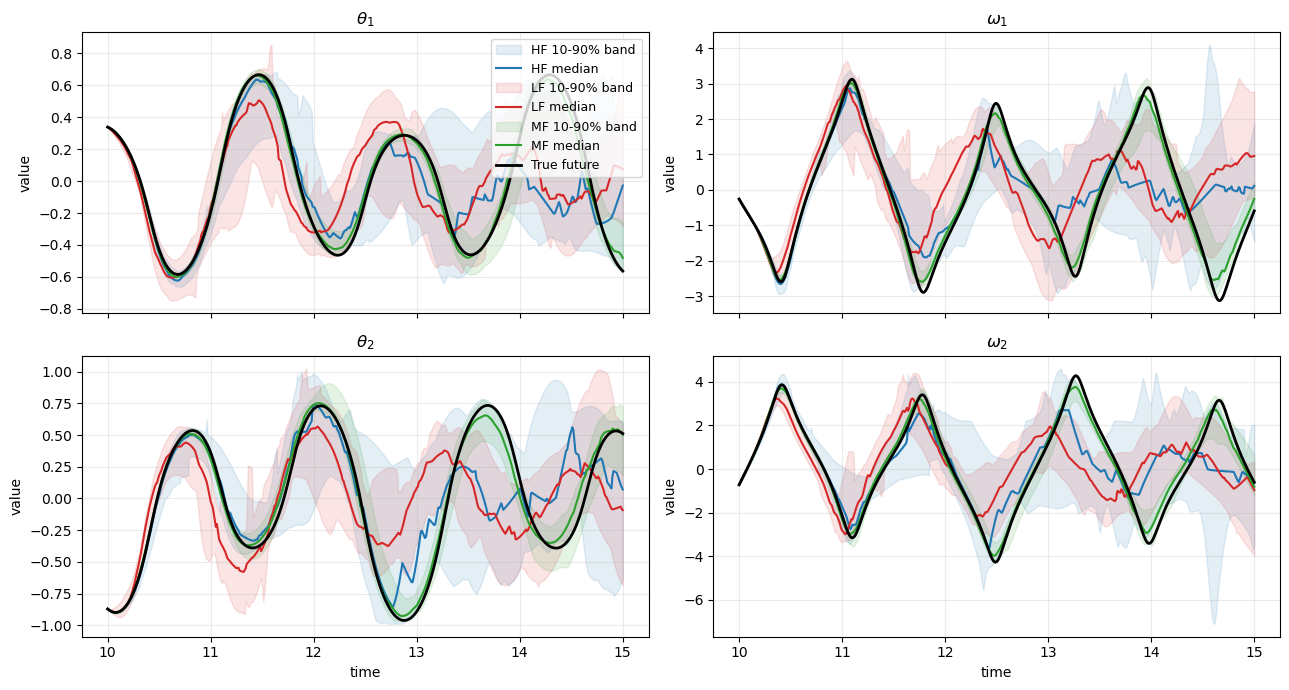

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True)

for model_name in fit_results:
    forecast_summary = forecast_summaries[model_name]
    median_forecast = forecast_summary["median"]
    lower_forecast = forecast_summary["lower"]
    upper_forecast = forecast_summary["upper"]

    for idx, ax in enumerate(axes.ravel()):
        ax.fill_between(
            t_future_abs,
            lower_forecast[:, idx],
            upper_forecast[:, idx],
            color=model_colors[model_name],
            alpha=0.12,
            label=f"{model_name} 10-90% band" if idx == 0 else None,
        )
        ax.plot(
            t_future_abs,
            median_forecast[:, idx],
            color=model_colors[model_name],
            lw=1.5,
            label=f"{model_name} median" if idx == 0 else None,
        )

for idx, ax in enumerate(axes.ravel()):
    ax.plot(t_future_abs, true_future[:, idx], color="black", lw=2.0, label="True future" if idx == 0 else None)
    ax.set_title(state_labels[idx])
    ax.set_ylabel("value")
    ax.grid(True, alpha=0.25)

axes[1, 0].set_xlabel("time")
axes[1, 1].set_xlabel("time")
axes[0, 0].legend(loc="upper right", fontsize=9)
plt.tight_layout()

print("Mean 10-90% forecast band width across all states and forecast times:")
for model_name, width in sorted(uncertainty_summary.items(), key=lambda item: item[1]):
    print(f"{model_name}: {width:.4f}")


Mean 10-90% derivative band width across all states and future times:
MF: 0.3644
HF: 0.4025
LF: 1.1857


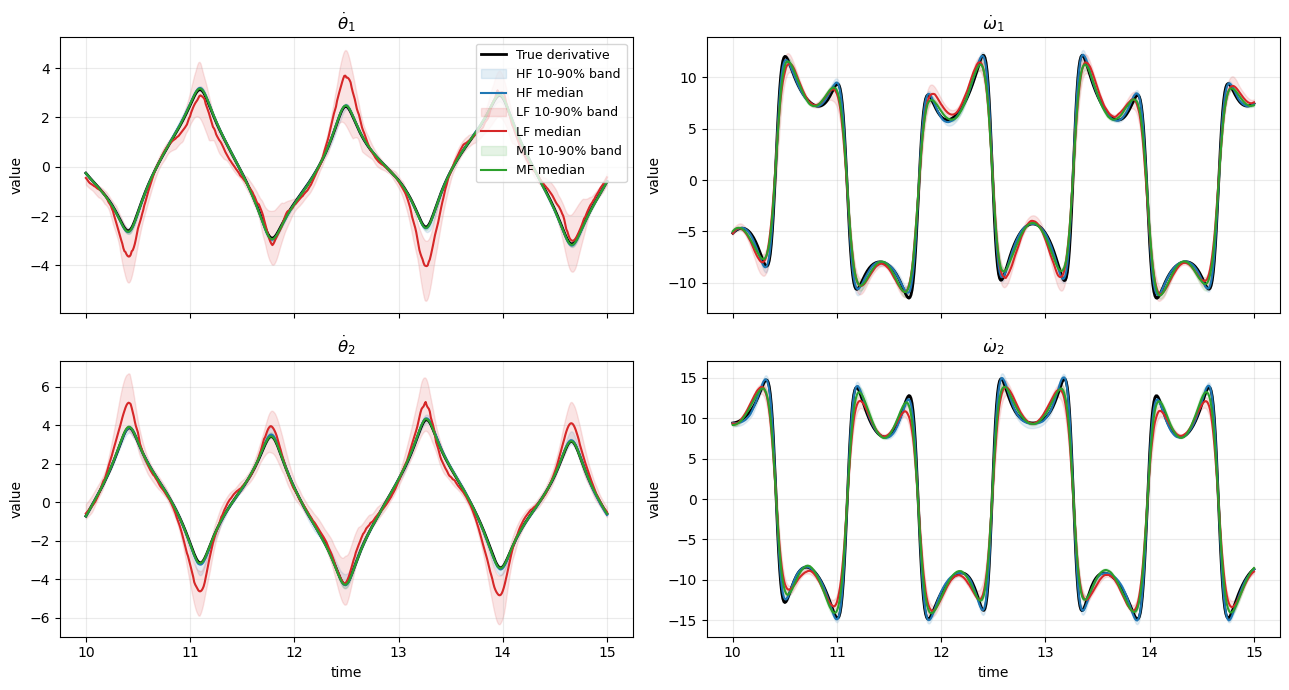

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True)
for idx, ax in enumerate(axes.ravel()):
    ax.plot(
        t_future_abs,
        true_future_derivatives[:, idx],
        color="black",
        lw=2.0,
        label="True derivative" if idx == 0 else None,
    )
    ax.set_title(derivative_labels[idx])
    ax.set_ylabel("value")
    ax.grid(True, alpha=0.25)
for model_name in fit_results:
    derivative_summary = derivative_summaries[model_name]
    median_derivatives = derivative_summary["median"]
    lower_derivatives = derivative_summary["lower"]
    upper_derivatives = derivative_summary["upper"]

    for idx, ax in enumerate(axes.ravel()):
        ax.fill_between(
            t_future_abs,
            lower_derivatives[:, idx],
            upper_derivatives[:, idx],
            color=model_colors[model_name],
            alpha=0.12,
            label=f"{model_name} 10-90% band" if idx == 0 else None,
        )
        ax.plot(
            t_future_abs,
            median_derivatives[:, idx],
            color=model_colors[model_name],
            lw=1.5,
            label=f"{model_name} median" if idx == 0 else None,
        )



axes[1, 0].set_xlabel("time")
axes[1, 1].set_xlabel("time")
axes[0, 0].legend(loc="upper right", fontsize=9)
plt.tight_layout()

print("Mean 10-90% derivative band width across all states and future times:")
for model_name, width in sorted(
    derivative_uncertainty_summary.items(),
    key=lambda item: item[1],
):
    print(f"{model_name}: {width:.4f}")


In [8]:
metric_rows = []

for model_name, metrics in evaluation.metrics.items():

    metric_rows.append(
        (
            model_name,
            metrics.forecast_rmse,
            metrics.forecast_width,
            metrics.forecast_coverage,
            metrics.derivative_rmse,
            metrics.derivative_width,
            metrics.derivative_coverage,
        )
    )

print(
    f"{'Model':<6} {'FcRMSE':>10} {'FcWidth':>10} {'FcCover':>10} {'DerRMSE':>10} {'DerWidth':>10} {'DerCover':>10}"
)
for row in sorted(metric_rows, key=lambda item: item[1]):
    print(
        f"{row[0]:<6} {row[1]:10.4f} {row[2]:10.4f} {row[3]:10.4f} {row[4]:10.4f} {row[5]:10.4f} {row[6]:10.4f}"
    )


Model      FcRMSE    FcWidth    FcCover    DerRMSE   DerWidth   DerCover
MF         0.1879     0.4729     0.8094     0.6646     0.3644     0.6118
HF         0.8699     1.8480     0.7944     0.2276     0.4025     0.7285
LF         1.1550     1.5115     0.5978     0.9549     1.1857     0.5808


In [ ]:
benchmark_seeds = list(range(5))

benchmark_rows = benchmark_double_pendulum_fidelities(
    benchmark_seeds,
    n_hf=1,
    n_lf=5,
    t_final=10.0,
    dt=0.01,
    hf_noise_scale=DEFAULT_HF_NOISE_SCALE,
    lf_noise_scale=DEFAULT_LF_NOISE_SCALE,
    theta_range=DEFAULT_THETA_RANGE,
    omega_range=DEFAULT_OMEGA_RANGE,
    library_kind=LIBRARY_KIND,
    poly_degree=DEFAULT_POLY_DEGREE,
    stlsq_threshold=0.5,
    stlsq_alpha=1e-12,
    n_ensemble_models=25,
    n_weak_cells=200,
    weak_window_length=0.05,
    forecast_horizon=forecast_horizon,
    forecast_dt=forecast_dt,
)
benchmark_summary = summarize_fidelity_benchmark(benchmark_rows)

print(
    f"{'Model':<6} {'n':>4} {'FcRMSE':>10} {'FcWidth':>10} {'FcCover':>10} {'FcValid':>10} {'DerRMSE':>10} {'DerWidth':>10} {'DerCover':>10} {'DerValid':>10}"
)
for row in sorted(benchmark_summary, key=lambda item: item['forecast_rmse_mean']):
    print(
        f"{row['model']:<6} {row['n_seeds']:4d} {row['forecast_rmse_mean']:10.4f} {row['forecast_width_mean']:10.4f} {row['forecast_coverage_mean']:10.4f} {row['forecast_valid_fraction_mean']:10.4f} {row['derivative_rmse_mean']:10.4f} {row['derivative_width_mean']:10.4f} {row['derivative_coverage_mean']:10.4f} {row['derivative_valid_fraction_mean']:10.4f}"
    )


/Users/filippozacchei/anaconda3/envs/mfsindy/lib/python3.12/site-packages/pysindy/utils/_axes.py:125: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Users/filippozacchei/anaconda3/envs/mfsindy/lib/python3.12/site-packages/pysindy/utils/_axes.py:125: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
/Users/filippozacchei/anaconda3/envs/mfsindy/lib/python3.12/site-packages/pysindy/utils/_axes.py:125: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
